# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE
print(os.getcwd())
print(os.listdir())
file_path_ump = "HuangBoZhi_hw3/Japan_unemp.csv"


# 2. Acquire and load your primary dataset
# YOUR CODE HERE
df = pd.read_csv(file_path_ump)
df.head()

c:\Users\joe20\OneDrive\文件\GitHub\datascience-publicpolicy-2026\notebooks\hw\hw_3
['HuangBoZhi_hw3', 'HuangBoZhi_hw3.ipynb']


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,...,OBS_VALUE,Observation value,BASE_PER,Base period,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_INDIC(1.0),Infra-annual labour statistics,I,JPN,Japan,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,3.1,NaN,NaN,NaN,A,Normal value,0,Units,1,One
1,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_INDIC(1.0),Infra-annual labour statistics,I,JPN,Japan,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,3.2,NaN,NaN,NaN,A,Normal value,0,Units,1,One
2,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_INDIC(1.0),Infra-annual labour statistics,I,JPN,Japan,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,3.1,NaN,NaN,NaN,A,Normal value,0,Units,1,One
3,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_INDIC(1.0),Infra-annual labour statistics,I,JPN,Japan,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,2.8,NaN,NaN,NaN,A,Normal value,0,Units,1,One
4,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_INDIC(1.0),Infra-annual labour statistics,I,JPN,Japan,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,4.7,NaN,NaN,NaN,A,Normal value,0,Units,1,One


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*  
OECD Data Explorer: DSD_LFS@DF_IALFS_INDIC(Unemployment), DSD_PRICES@DF_PRICES_ALL(CPI)

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 132 non-null    object 
 1   STRUCTURE_ID              132 non-null    object 
 2   STRUCTURE_NAME            132 non-null    object 
 3   ACTION                    132 non-null    object 
 4   REF_AREA                  132 non-null    object 
 5   Reference area            132 non-null    object 
 6   MEASURE                   132 non-null    object 
 7   Measure                   132 non-null    object 
 8   UNIT_MEASURE              132 non-null    object 
 9   Unit of measure           132 non-null    object 
 10  TRANSFORMATION            132 non-null    object 
 11  Transformation            132 non-null    object 
 12  ADJUSTMENT                132 non-null    object 
 13  Adjustment                132 non-null    object 
 14  SEX       

,Time period,OBS_VALUE,Observation value,BASE_PER,Base period,UNIT_MULT,DECIMALS
count,0.0,132.000000,0.0,0.0,0.0,132.0,132.0
mean,NaN,3.496970,NaN,NaN,NaN,0.0,1.0
std,NaN,0.888428,NaN,NaN,NaN,0.0,0.0
min,NaN,2.100000,NaN,NaN,NaN,0.0,1.0
25%,NaN,2.800000,NaN,NaN,NaN,0.0,1.0
50%,NaN,3.400000,NaN,NaN,NaN,0.0,1.0
75%,NaN,4.200000,NaN,NaN,NaN,0.0,1.0
max,NaN,5.400000,NaN,NaN,NaN,0.0,1.0


In [3]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE
df = df.rename(columns={"OBS_VALUE": "Unemployment rate"})

In [4]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE
df = df[["TIME_PERIOD", "Unemployment rate"]]
df.head()

,TIME_PERIOD,Unemployment rate
0,2015-10,3.1
1,2015-11,3.2
2,2020-10,3.1
3,2020-04,2.8
4,2011-05,4.7


In [5]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE
df = df.dropna(subset=["TIME_PERIOD", "Unemployment rate"])

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
file_path_CPI = "HuangBoZhi_hw3/Japan_CPI.csv"
df1 = pd.read_csv(file_path_CPI)
# Rename columns and select a clean subset
df1 = df1.rename(columns={"OBS_VALUE": "CPI"})
# Filter row or column filters if necessary
df1 = df1[["TIME_PERIOD", "CPI"]]
df1.head()

,TIME_PERIOD,CPI
0,2017-11,0.6
1,2017-12,1.0
2,2010-08,-0.9
3,2015-12,0.2
4,2016-01,-0.1


In [ ]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
merged_df = pd.merge(df1, df, on="TIME_PERIOD", how="inner")
merged_df.head()

### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*  
I merge by TIME_PERIOD

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE
# Get year from TIME_PERIOD
merged_df["year_label"] = merged_df["TIME_PERIOD"].str.split("-").str[0].astype(int)

# filter from 2010-2020
df_2010_2020 = merged_df[
    (merged_df["year_label"] >= 2010) & 
    (merged_df["year_label"] <= 2020)
].copy()

# Groupby every year
year_mean = df_2010_2020.groupby("year_label").mean(numeric_only=True)

year_mean

,CPI,Unemployment rate
year_label,,
2010,-0.700000,5.050000
2011,-0.275000,4.583333
2012,-0.041667,4.350000
2013,0.350000,4.025000
2014,2.733333,3.591667
2015,0.800000,3.375000
2016,-0.133333,3.116667
2017,0.475000,2.808333
2018,0.991667,2.441667


- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

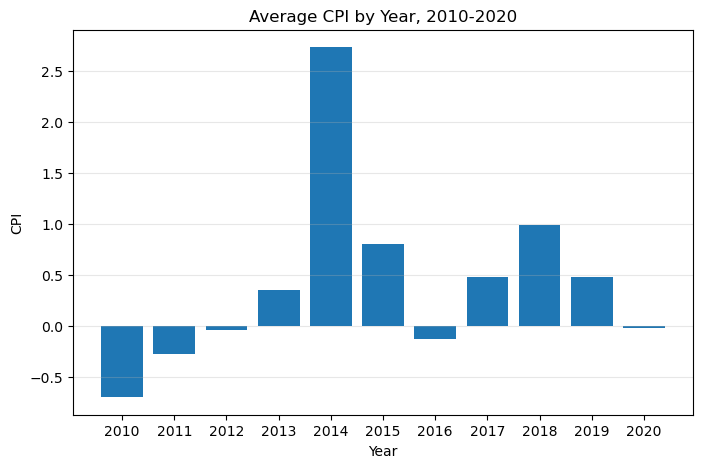

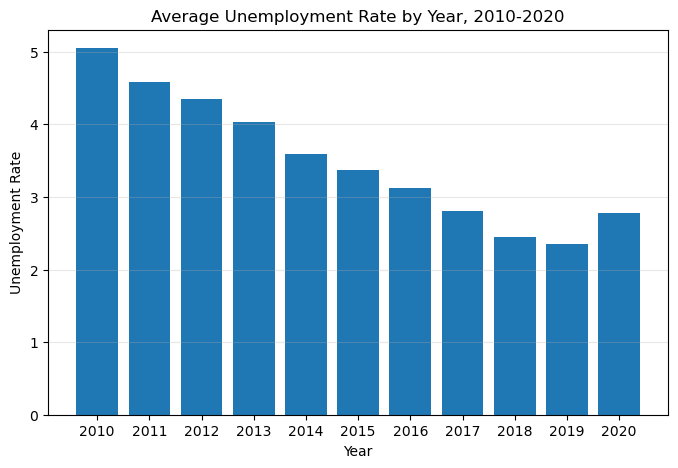

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
import matplotlib.pyplot as plt

# First：CPI
plt.figure(figsize=(8, 5))
plt.bar(year_mean.index, year_mean["CPI"])
plt.title("Average CPI by Year, 2010-2020")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.xticks(year_mean.index)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Second：Unemployment rate
plt.figure(figsize=(8, 5))
plt.bar(year_mean.index, year_mean["Unemployment rate"])
plt.title("Average Unemployment Rate by Year, 2010-2020")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.xticks(year_mean.index)
plt.grid(axis="y", alpha=0.3)
plt.show()

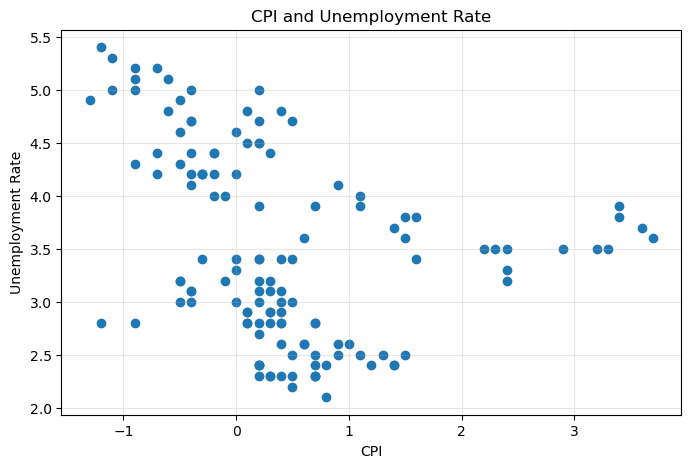

In [10]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    merged_df["CPI"],
    merged_df["Unemployment rate"]
)

plt.title("CPI and Unemployment Rate")
plt.xlabel("CPI")
plt.ylabel("Unemployment Rate")
plt.grid(alpha=0.3)

plt.show()

                            OLS Regression Results                            
Dep. Variable:      Unemployment rate   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     14.37
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           0.000229
Time:                        14:31:58   Log-Likelihood:                -164.26
No. Observations:                 132   AIC:                             332.5
Df Residuals:                     130   BIC:                             338.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6125      0.080     45.318      0.0

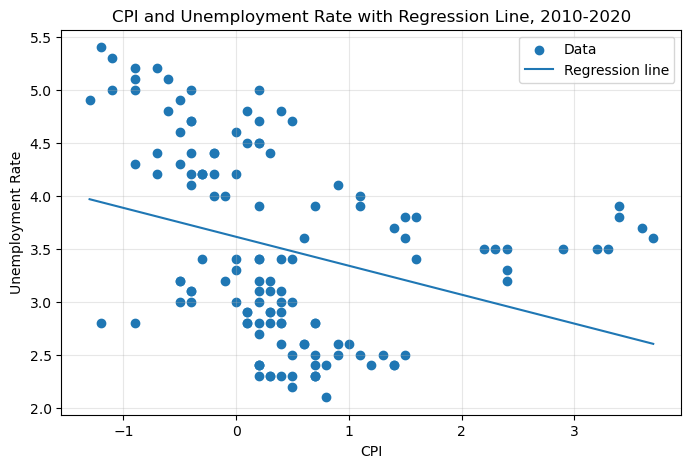

In [11]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE
import matplotlib.pyplot as plt
import statsmodels.api as sm

# dropna
reg_df = merged_df.dropna(subset=["CPI", "Unemployment rate"]).copy()

# set x and y
X = reg_df["CPI"]
y = reg_df["Unemployment rate"]

# plus constant
X_with_const = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X_with_const)
results = model.fit()

# print regression summary table
print(results.summary())

# make prediction value
reg_df["predicted_unemployment"] = results.predict(X_with_const)

# sort by CPI
reg_df_sorted = reg_df.sort_values("CPI")

# Draw scatter plot + regression line
plt.figure(figsize=(8, 5))

plt.scatter(
    reg_df_sorted["CPI"],
    reg_df_sorted["Unemployment rate"],
    label="Data"
)

plt.plot(
    reg_df_sorted["CPI"],
    reg_df_sorted["predicted_unemployment"],
    label="Regression line"
)

plt.title("CPI and Unemployment Rate with Regression Line, 2010-2020")
plt.xlabel("CPI")
plt.ylabel("Unemployment Rate")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*  

The scatter plot shows a negative relationship between CPI and the unemployment rate. As CPI increases, the unemployment rate tends to decrease. The regression line also slopes downward, supporting this negative association.

The OLS results show that the coefficient on CPI is -0.2727, meaning that a one-unit increase in CPI is associated with a 0.273 percentage point decrease in the unemployment rate. The coefficient is statistically significant, as the p-value is close to zero. However, the R-squared is 0.100, indicating that CPI explains only about 10% of the variation in unemployment. Therefore, CPI has a statistically significant but limited explanatory power for unemployment in this dataset.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.